In [ ]:
# ============================================================
# PRACTICAL: Employee Satisfaction - Hypothesis Testing
# ============================================================

# -------------------------------------------------------
# CONCEPT 1: HYPOTHESIS TESTING
# -------------------------------------------------------
# H0 (Null)        = All groups are EQUAL (assume true first)
# H1 (Alternative) = At least one group is DIFFERENT
# TRICK: "P is LOW → H0 must GO"
# P < 0.05 → REJECT H0 → Significant difference EXISTS
# P > 0.05 → ACCEPT H0 → No significant difference

# -------------------------------------------------------
# CONCEPT 2: P-VALUE
# -------------------------------------------------------
# P-value = probability that H0 is true
# Think of it as a threshold:
# Below 0.05 = something meaningful is happening
# Above 0.05 = could just be random chance

# -------------------------------------------------------
# CONCEPT 3: F-STATISTIC
# -------------------------------------------------------
# F = Variation BETWEEN groups / Variation WITHIN groups
# High F = groups are very different from each other
# Low F  = groups are similar to each other
# F and P always come together in ANOVA

# -------------------------------------------------------
# CONCEPT 4: ONE-WAY ANOVA
# -------------------------------------------------------
# Tests ONE factor effect on scores
# Example: Does LOCATION affect satisfaction?
# Compares means of 3+ groups in one test
# H0 = All locations have same mean satisfaction
# H1 = At least one location differs

# -------------------------------------------------------
# CONCEPT 5: TWO-WAY ANOVA
# -------------------------------------------------------
# Tests TWO factors simultaneously
# Example: Does LOCATION + DEPARTMENT affect satisfaction?
# Gives 3 results:
#   1. Effect of Location alone
#   2. Effect of Department alone
#   3. INTERACTION effect (Location x Department)
# Interaction = when two factors COMBINE to create unique effect
# Example of interaction:
#   Delhi + HR = very high score
#   Delhi + IT = very low score
#   = location effect DEPENDS on department

# -------------------------------------------------------
# CONCEPT 6: TUKEY'S HSD (Post-Hoc Test)
# -------------------------------------------------------
# ANOVA only says "some difference exists"
# Tukey tells EXACTLY which pairs are different
# Example output:
#   Mumbai vs Delhi    → reject=True  → they ARE different
#   Mumbai vs Bangalore → reject=False → they are NOT different
# meandiff = actual score difference between two groups
# p-adj    = adjusted p-value for that specific pair
# reject   = True means significant difference

# -------------------------------------------------------
# CONCEPT 7: STRATIFIED SAMPLING
# -------------------------------------------------------
# Divides data into groups first, then samples from each
# WHY: Simple random might miss small departments
# HOW: Each group sampled proportionally
# Example:
#   HR = 500 employees → pick 54
#   IT = 2000 employees → pick 214
#   Finance = 300 employees → pick 32
# Result: Every group is fairly represented

# -------------------------------------------------------
# CONCEPT 8: OUTLIER DETECTION
# -------------------------------------------------------
# METHOD 1 - Z-SCORE:
#   Z = (value - mean) / standard deviation
#   Z > 3  = outlier on high side
#   Z < -3 = outlier on low side
#   Most normal values fall between -3 and +3
#
# METHOD 2 - BOXPLOT:
#   IQR = Q3 - Q1
#   Upper fence = Q3 + 1.5 x IQR
#   Lower fence = Q1 - 1.5 x IQR
#   Dots beyond fences = outliers

# -------------------------------------------------------
# KEY NUMBERS TO REPORT IN CONCLUSION
# -------------------------------------------------------
# F-statistic → how different groups are
# P-value     → is difference significant? (threshold 0.05)
# meandiff    → actual score gap between groups
# reject      → True/False for each pair in Tukey

# -------------------------------------------------------
# QUICK REFERENCE
# -------------------------------------------------------
# P < 0.05  → Significant → Reject H0  ✅
# P > 0.05  → Not significant → Accept H0 ❌
# Z > 3     → Outlier ❌
# Z < -3    → Outlier ❌
# One-Way   → 1 factor tested
# Two-Way   → 2 factors + interaction tested
# Tukey     → which specific pairs differ

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("HR_capstone_dataset.csv")

In [ ]:
df.shape
# row,column aapse

(14999, 10)

In [5]:
df.isnull().sum()
#ketli null and missing value che a khabar padse

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [ ]:
# Checking column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
#Task-1 Data Curation & Sampling->stratified random sampling

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
stratified_random_sample = df.groupby("Department", group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42)
)
#here first using group by is convert all department group , group key flase menase dont chage it index and after .sample() = randomly picks rows from dataframe and  frac=0.1  = pick 10% of total rows

print("Before sampling shape:",df.shape)
print("After sampling shape:",stratified_random_sample.shape)
print(stratified_random_sample["Department"].value_counts())
# What this does:
# Original data  → 100% of employees
# After sampling → 30% picked

# BUT every department is 
# proportionally represented 

Before sampling shape: (14999, 10)
After sampling shape: (1501, 10)
Department
sales          414
technical      272
support        223
IT             123
product_mng     90
marketing       86
RandD           79
accounting      77
hr              74
management      63
Name: count, dtype: int64


/var/folders/m_/mkmgvrh50sjbfhzz0vscx1tw0000gn/T/ipykernel_80052/2733183502.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_random_sample = df.groupby("Department", group_keys=False).apply(


In [ ]:
# stratified_random_sample = df.groupby("Department", group_keys=False).apply(
#     lambda x: x.sample(frac=0.1, random_state=42)
# )

# ## Break it into parts:

# ### Part 1 — `df.groupby("Department")`
# Takes your data and DIVIDES it by Department

# Example:
# HR group     → [row1, row5, row9...]
# IT group     → [row2, row6, row10...]
# Finance group → [row3, row7, row11...]

# Like sorting cards by suit! 🃏

# ### Part 2 — `group_keys=False`
# Just a technical setting
# Keeps original index numbers
# Don't worry about this much

# ### Part 3 — `.apply(lambda x: ...)`

# "For EACH group, do something"
# lambda x = x is each group one by one
#            HR group first
#            then IT group
#            then Finance group

# ### Part 4 — `x.sample(frac=0.1, random_state=42)`

# frac=0.1 means → pick 10% randomly from each group

# Example:
# HR has 100 employees → pick 10
# IT has 200 employees → pick 20
# Finance has 50 employees → pick 5

# random_state=42 → same random picks every time
#                   so results are reproducible
# ```

# ---

# ## Full Flow in Simple Words:

# Step 1: Divide employees by Department
#         HR / IT / Finance / Marketing...

# Step 2: From EACH department
#         pick 10% randomly

# Step 3: Combine all picked employees
#         into one new dataset

# Result: Every department is represented! ✅


# ## Real Life Analogy:

# Imagine a school with:
# Class A = 40 students
# Class B = 30 students  
# Class C = 20 students

# You want 10% from each class
# for a survey:

# Class A → pick 4 students
# Class B → pick 3 students
# Class C → pick 2 students

# Total = 9 students
# All classes represented! ✅

# That's exactly what your code does
# but with Departments!

# ## Why not just random sample?

# Without stratified:
# df.sample(frac=0.1)

# Might pick:
# HR = 8 employees
# IT = 1 employee   ← too few!
# Finance = 0 employees ← missing completely! ❌

# With stratified:
# Every department gets fair representation ✅

In [ ]:
#Task-2 Outliers->Box-Plot and Z-Score

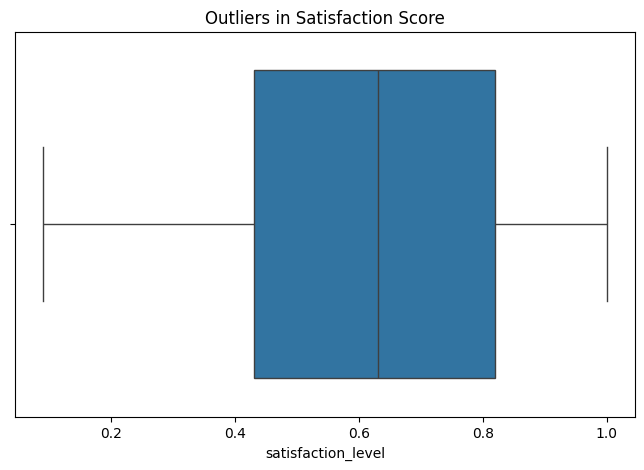

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=stratified_random_sample['satisfaction_level'])
plt.title('Outliers in Satisfaction Score')
plt.show()

In [15]:
from scipy import stats

z_scores = np.abs(stats.zscore(
           stratified_random_sample['satisfaction_level']))

outliers = stratified_random_sample[z_scores > 3]
print("Total outliers found:", len(outliers))
print(outliers)

Total outliers found: 0
Empty DataFrame
Columns: [satisfaction_level, last_evaluation, number_project, average_montly_hours, time_spend_company, Work_accident, left, promotion_last_5years, Department, salary]
Index: []


In [19]:
print(df.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')


In [ ]:
#Task-3 : ANOVA
# One-Way ANOVA question becomes:
# "Does SALARY level affect satisfaction?"


In [20]:
print(df['salary'].unique())
print(df['Department'].unique())

['low' 'medium' 'high']
['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']


In [ ]:
# One-Way ANOVA question becomes:
# "Does SALARY level affect satisfaction?"

# Instead of:
# "Does LOCATION affect satisfaction?"

# salary has groups: low, medium, high
# = perfect for ANOVA! ✅

In [ ]:
from scipy import stats

# Separate satisfaction scores by salary group

# Give me satisfaction_level of employees WHERE salary == 'low'
low = stratified_random_sample[
        stratified_random_sample['salary']=='low']['satisfaction_level']

# Give me satisfaction_level of employees WHERE salary == 'medium'
medium = stratified_random_sample[
          stratified_random_sample['salary']=='medium']['satisfaction_level']

# Give me satisfaction_level of employees WHERE salary == 'high'
high = stratified_random_sample[
        stratified_random_sample['salary']=='high']['satisfaction_level']

# Run One-Way ANOVA
f_stat, p_value = stats.f_oneway(low, medium, high)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 ")
    print("Salary DOES affect satisfaction level")
else:
    print("Result: Accept H0 ")
    print("Salary does NOT affect satisfaction level")


# ## What we are testing:
# H0 = low, medium, high salary groups
#      have SAME satisfaction level
# H1 = at least one salary group has
#      DIFFERENT satisfaction level

# f_oneway() = One Way ANOVA function
# f_stat  = how different groups are
# p_value = is difference significant?

F-statistic: 0.5761492106273876
P-value: 0.5621830726256534
Result: Accept H0 
Salary does NOT affect satisfaction level


In [ ]:
#Task-4 Two-way Anvoa
# Tests THREE things at once:
# 1. Does SALARY affect satisfaction?
# 2. Does DEPARTMENT affect satisfaction?
# 3. Do SALARY + DEPARTMENT TOGETHER 
#    affect satisfaction?

In [28]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 1.8 MB/s  0:00:05m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Build the model
model = ols('satisfaction_level ~ C(salary) + C(Department) + C(salary):C(Department)', 
             data=stratified_random_sample).fit()

# Run Two-Way ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


## What each part means:

# 'satisfaction_level ~ C(salary) + C(Department) + C(salary):C(Department)'

# satisfaction_level  → target (what we predict)
# C(salary)          → factor 1
# C(Department)      → factor 2
# C(salary):C(Department) → interaction effect
# C() means → treat as category not number

# ### Three things being tested:
# Row 1: C(salary)                → salary alone
# Row 2: C(Department)            → department alone  
# Row 3: C(salary):C(Department)  → both together


# ## How to interpret output:

# Each row has a P-value
# P < 0.05 → that factor is significant 
# P > 0.05 → that factor is not significant 

                            sum_sq      df         F    PR(>F)
C(salary)                 0.092583     2.0  0.751417  0.471879
C(Department)             0.375634     9.0  0.677489  0.729944
C(salary):C(Department)   1.043499    18.0  0.941022  0.527715
Residual                 90.621742  1471.0       NaN       NaN
